# Evaluación final

Acá no se elige nada. Las decisiones ya están tomadas y medidas: el **modelo** en `03_modeling.ipynb`,
los **hiperparámetros** en `04_tuning.ipynb` —que los dejó en `models/mejores_parametros.json`— y el
**umbral** sale de la regla de negocio, no de los datos.

Lo que queda es medir **una sola vez** sobre los 9 días reservados desde el 13 de abril, explicar qué
mira el modelo, guardar el artefacto y decir qué habría que vigilar en producción. Una sola vez porque,
si se mirara el resultado y después se cambiara algo, ese período pasaría a ser otro conjunto de
validación y el número final dejaría de significar lo que dice.

## 1. El disparo final

El modelo se entrena con **todo** desarrollo y se aplica una vez sobre el período reservado, con el
umbral 0,2 y el corte de `score` que ganó en desarrollo. Van tres variantes: el de defecto, el ajustado
y el ajustado **sin `score`**, que es el número válido si `score` resultara no estar disponible al
decidir el pago.

**Hipótesis.** La ganancia sobre aprobar todo tendría que ser del mismo orden que en validación una vez
ajustada por tamaño del período, y **la ventaja del ajustado sobre el de defecto tendría que encogerse
respecto de los +5.127** que midió `04`. Sacar `score` debería costar algo parecido al 15% que costó en
los folds, no derrumbar el modelo.

In [1]:
import numpy as np
import pandas as pd
import shap
from matplotlib import pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

from fraud_detection.constants import (
    DATE,
    EXPERIMENTO_EVALUACION,
    N_SPLITS,
    RANDOM_STATE,
    TARGET,
)
from fraud_detection.dataset import load_periods
from fraud_detection.evaluation import (
    expected_gain,
    gain_by_policy,
    optimal_probability_threshold,
    sweep_gain,
)
from fraud_detection.features import build_preprocessor
from fraud_detection.modeling import temporal_folds
from fraud_detection.paths import MODELS_DIR, ROOT
from fraud_detection.plots import PALETTE
from fraud_detection.tracking import configurar, mlflow, registrar
from fraud_detection.training import XGBOOST_DEFAULT, build_model, load_model, save_model, train
from fraud_detection.tuning import load_best

development, test = load_periods()
X, y = development.drop(columns=[TARGET]), development[TARGET]
folds = list(temporal_folds(development[DATE], n_splits=N_SPLITS))
UMBRAL = optimal_probability_threshold()
GRILLA = np.round(np.arange(0.02, 0.62, 0.01), 2)

configuracion = load_best()
AJUSTADO = configuracion["parametros"]
print("store de experimentos:", configurar(EXPERIMENTO_EVALUACION))
print(
    f"configuración de 04: +{configuracion['ganancia_validacion']:,.0f} en validación, "
    f"umbral {configuracion['umbral']}"
)

sin_etiqueta = test.drop(columns=[TARGET])
corte_score = sweep_gain(development, development.score, range(0, 101)).idxmax()
politicas = {
    "aprobar todo": pd.Series(True, index=test.index),
    f"regla score < {corte_score}": test.score.lt(corte_score).fillna(False),
}

entrenados = {}
for nombre, parametros, use_score in [
    ("defecto", XGBOOST_DEFAULT, True),
    ("ajustado", AJUSTADO, True),
    ("ajustado sin score", AJUSTADO, False),
]:
    entrenados[nombre] = train(development, XGBClassifier(**parametros), use_score=use_score)
    probabilidad = pd.Series(entrenados[nombre].predict_proba(sin_etiqueta)[:, 1], index=test.index)
    politicas[f"xgboost {nombre}, p < 0,2"] = probabilidad.lt(UMBRAL)
    # La brecha contra desarrollo cierra el diagnóstico de sobreajuste de la sección 3 de 04.
    auc_train = roc_auc_score(y, entrenados[nombre].predict_proba(X)[:, 1])
    auc_reservado = roc_auc_score(test[TARGET], probabilidad)
    print(
        f"{nombre:18} auc {auc_reservado:.4f} | "
        f"ap {average_precision_score(test[TARGET], probabilidad):.4f} | "
        f"probabilidad media {probabilidad.mean():.4f} | "
        f"auc train {auc_train:.4f} | brecha {auc_train - auc_reservado:+.4f}"
    )

politicas["maximo alcanzable"] = test[TARGET].eq(0)
print(
    f"entrenados con {len(development):,} transacciones de "
    f"{development[DATE].dt.normalize().nunique()} días"
)
holdout = gain_by_policy(test, politicas)
holdout["sobre_aprobar_todo"] = holdout.ganancia - holdout.loc["aprobar todo", "ganancia"]
display(holdout.round(2))

mejora = holdout.sobre_aprobar_todo
ajustado, defecto = mejora["xgboost ajustado, p < 0,2"], mejora["xgboost defecto, p < 0,2"]
sin_score, regla = (
    mejora["xgboost ajustado sin score, p < 0,2"],
    mejora[f"regla score < {corte_score}"],
)
en_validacion = configuracion["ganancia_validacion"] - configuracion["ganancia_validacion_defecto"]
print(
    f"Ajustado sobre defecto: {ajustado - defecto:+,.0f}, el {(ajustado - defecto) / en_validacion:.1%} "
    f"de los {en_validacion:+,.0f} de validación"
)
print(
    f"Con score sobre sin score: {ajustado - sin_score:+,.0f}, el "
    f"{(ajustado - sin_score) / ajustado:.1%} de la mejora sobre aprobar todo"
)
print(
    f"Veces la regla sobre score: ajustado {ajustado / regla:.2f}, sin score {sin_score / regla:.2f} | "
    f"captura el {ajustado / mejora['maximo alcanzable']:.1%} de lo que está en disputa"
)

probabilidad_final = pd.Series(
    entrenados["ajustado"].predict_proba(sin_etiqueta)[:, 1], index=test.index
)
barrido = sweep_gain(test, probabilidad_final, GRILLA)
print(
    f"{len(test):,} transacciones | {test[DATE].dt.normalize().nunique()} días | "
    f"{test[TARGET].mean():.2%} de fraude"
)
perdido = barrido.max() - expected_gain(test, probabilidad_final.lt(UMBRAL))
print(
    f"El mejor corte sobre este mismo período habría sido {barrido.idxmax()}, con "
    f"{perdido:,.0f} más que el 0,2 teórico, el {perdido / ajustado:.1%} de la mejora"
)

corrida = registrar(
    "holdout xgboost ajustado",
    parametros={**AJUSTADO, "umbral": UMBRAL},
    metricas={
        "ganancia": holdout.loc["xgboost ajustado, p < 0,2", "ganancia"],
        "sobre_aprobar_todo": holdout.loc["xgboost ajustado, p < 0,2", "sobre_aprobar_todo"],
        "pct_del_maximo": holdout.loc["xgboost ajustado, p < 0,2", "pct_del_maximo"],
        "auc": roc_auc_score(test[TARGET], probabilidad_final),
        "ap": average_precision_score(test[TARGET], probabilidad_final),
    },
    etiquetas={"etapa": "periodo reservado", "variante": "con score"},
)
print("corrida registrada en MLflow:", corrida)

store de experimentos: sqlite:////Users/matiasmoyano/repositories/mercadolibre-fraud-detection/mlflow.db
configuración de 04: +133,828 en validación, umbral 0.2


defecto            auc 0.8889 | ap 0.4470 | probabilidad media 0.0469 | auc train 0.9429 | brecha +0.0540


ajustado           auc 0.8885 | ap 0.4450 | probabilidad media 0.0475 | auc train 0.9207 | brecha +0.0322


ajustado sin score auc 0.8468 | ap 0.3477 | probabilidad media 0.0497 | auc train 0.8954 | brecha +0.0486
entrenados con 114,506 transacciones de 36 días


,ganancia,pct_del_maximo,aprobadas,aprobadas_pct,fraudes_aprobados,sobre_aprobar_todo
aprobar todo,226254.46,65.70,35494.0,100.00,1571.0,0.00
regla score < 91,249455.56,72.44,33933.0,95.60,1066.0,23201.11
"xgboost defecto, p < 0,2",273656.99,79.46,33585.0,94.62,807.0,47402.53
"xgboost ajustado, p < 0,2",273821.35,79.51,33564.0,94.56,803.0,47566.89
"xgboost ajustado sin score, p < 0,2",264121.91,76.69,33571.0,94.58,924.0,37867.45
maximo alcanzable,344380.70,100.00,33923.0,95.57,0.0,118126.25


Ajustado sobre defecto: +164, el 3.2% de los +5,127 de validación
Con score sobre sin score: +9,699, el 20.4% de la mejora sobre aprobar todo
Veces la regla sobre score: ajustado 2.05, sin score 1.63 | captura el 40.3% de lo que está en disputa
35,494 transacciones | 9 días | 4.43% de fraude
El mejor corte sobre este mismo período habría sido 0.19, con 728 más que el 0,2 teórico, el 1.5% de la mejora


corrida registrada en MLflow: 34680fdcbacd450ab8ef2667469c68a8


**Lectura: el modelo rinde, y la hipótesis sobre el ajuste se confirma.**

**El modelo ajustado agrega +47.567 sobre aprobar todo en el período reservado, contra +23.201 de la
regla de un corte sobre `score`.** Poco más del doble. Captura el **40%** de los 118.126 en disputa, deja
pasar 803 fraudes contra los 1.571 de aprobar todo, y para eso rechaza el 5,4% de las transacciones.

**Del ajuste sobrevivió muy poco.** En validación el ajustado le sacaba +5.127 al de defecto; acá le
saca **+164**, un 3% de aquella diferencia, con un AUC un pelo menor (0,8885 contra 0,8889). La mayor
parte de esos +5.127 era la suerte de haber elegido la mejor de 40 combinaciones, no aprendizaje. Lo que sí sobrevivió es la generalización
que midió `04`: la brecha entre desarrollo y período reservado es **0,0322** en el ajustado contra
**0,0540** en el de defecto.

**El umbral teórico volvió a aguantar.** El mejor corte habría sido 0,19, con **728** más que el 0,2: un
1,5% de la ganancia. En desarrollo el óptimo de cada fold caía entre 0,12 y 0,15: el óptimo empírico se
mueve de período en período, y el 0,2 de la regla de negocio nunca queda lejos.

**Sin `score`, el modelo sigue en pie**: **+37.867**, un 20% menos, con AUC 0,8468 y 924 fraudes
aprobados en vez de 803. Sigue siendo **1,6 veces** la regla sobre `score`, que sí la usa. La hipótesis
apuntaba a un costo cercano al 15%; fue algo mayor, pero del mismo orden.

## 2. Abrir el número: de qué está hecho y cuánto puede moverse

El +47.567 es un número puntual sobre 35.494 transacciones de 9 días, y así presentado parece exacto.
Faltan tres cosas: **de qué aciertos y errores está hecho**, **cuánto podría moverse solo por azar**, y
**si se reparte parejo** entre días y entre países.

Nada de esto es una decisión nueva: son cortes distintos de la misma y única pasada. No se elige nada a
partir de ellos, así que la regla de tocar el período reservado una sola vez sigue en pie.

**La cuenta que hace posibles los tres cortes.** Frente a aprobar todo, las transacciones aprobadas no
cambian nada y cada rechazo suma o resta:

- rechazar un **fraude** salva su monto entero;
- rechazar una **legítima** cuesta el 25% que se habría ganado con ella.

Sumando eso transacción por transacción tiene que dar exactamente el +47.567 de la tabla anterior. Y como
es una suma, se puede partir por día o por país sin que deje de cerrar.

**Hipótesis para la matriz de confusión.** Con 4,43% de fraude y un umbral de 0,2 —que es bajo— se
espera una **precisión baja**: la mayoría de lo que el modelo rechace va a ser legítimo. Y aun así la
ganancia tiene que ser la mejor, porque frenar un fraude vale cuatro veces lo que cuesta frenar una
legítima del mismo monto. Si eso es cierto, la matriz medida en pesos y la ganancia son el mismo número.

,transacciones,monto,efecto
legitima aprobada,32761.0,1283166.0,0.0
legitima rechazada,1162.0,94357.0,-23589.0
fraude aprobado,803.0,46970.0,0.0
fraude rechazado,768.0,71156.0,71156.0
total,35494.0,1495649.0,47567.0


,precision,recall,f1,especificidad,rechazadas,sobre_aprobar_todo
modelo,0.3979,0.4889,0.4387,0.9657,1930.0,47566.8925
regla score >= 91,0.3235,0.3215,0.3225,0.9689,1561.0,23201.1075


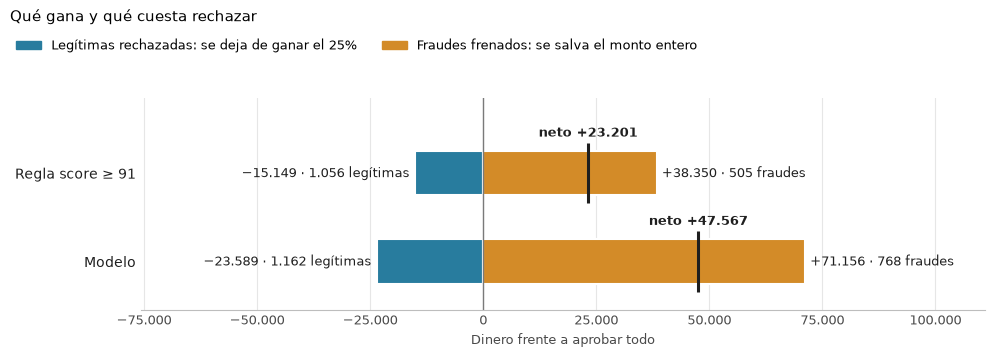

In [2]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from fraud_detection.constants import AMOUNT, GAIN_RATE
from fraud_detection.plots import plot_rejection_balance

rechaza_modelo = probabilidad_final.ge(UMBRAL)
rechaza_score = test.score.ge(corte_score).fillna(True)


def aporte_por_transaccion(rechaza: pd.Series) -> pd.Series:
    """Cuánto suma o resta cada transacción frente a aprobar todo."""
    efecto = np.where(test[TARGET].eq(1), 1.0, -GAIN_RATE)
    return pd.Series(np.where(rechaza, test[AMOUNT] * efecto, 0.0), index=test.index)


def celdas_de_la_matriz(rechaza: pd.Series) -> pd.DataFrame:
    """Las cuatro celdas, en transacciones, en monto y en efecto sobre aprobar todo."""
    aporte = aporte_por_transaccion(rechaza)
    grupos = {
        "legitima aprobada": test[TARGET].eq(0) & ~rechaza,
        "legitima rechazada": test[TARGET].eq(0) & rechaza,
        "fraude aprobado": test[TARGET].eq(1) & ~rechaza,
        "fraude rechazado": test[TARGET].eq(1) & rechaza,
    }
    tabla = pd.DataFrame(
        {
            nombre: {
                "transacciones": int(mascara.sum()),
                "monto": test.loc[mascara, AMOUNT].sum(),
                "efecto": aporte.loc[mascara].sum(),
            }
            for nombre, mascara in grupos.items()
        }
    ).T
    tabla.loc["total"] = tabla.sum()
    return tabla


aporte_modelo = aporte_por_transaccion(rechaza_modelo)
aporte_score = aporte_por_transaccion(rechaza_score)
np.testing.assert_allclose(
    aporte_modelo.sum(), holdout.loc["xgboost ajustado, p < 0,2", "sobre_aprobar_todo"]
)
display(celdas_de_la_matriz(rechaza_modelo).round(0))

clasificacion = {}
for nombre, rechaza in [
    ("modelo", rechaza_modelo),
    (f"regla score >= {corte_score}", rechaza_score),
]:
    aprobadas_ok, rechazadas_mal, aprobados_mal, rechazados_ok = confusion_matrix(
        test[TARGET], rechaza
    ).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        test[TARGET], rechaza, average="binary", zero_division=0
    )
    clasificacion[nombre] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "especificidad": aprobadas_ok / (aprobadas_ok + rechazadas_mal),
        "rechazadas": int(rechaza.sum()),
        "sobre_aprobar_todo": aporte_por_transaccion(rechaza).sum(),
    }
clasificacion = pd.DataFrame(clasificacion).T
display(clasificacion.round(4))

figura = plot_rejection_balance(
    {
        f"Regla score ≥ {corte_score}": celdas_de_la_matriz(rechaza_score),
        "Modelo": celdas_de_la_matriz(rechaza_modelo),
    }
)

**Lectura: la matriz medida en pesos *es* la ganancia, y ahí se ve por qué el umbral no es 0,5.**

El modelo rechaza 1.930 transacciones. De esas, **1.162 son legítimas y 768 son fraude**: solo 4 de
cada 10 rechazos son fraude. Es una precisión de **0,3979**, que en un problema de clasificación común
sería un mal número.

En pesos se ve por qué acá no lo es. Las 1.162 legítimas rechazadas suman 94.357 de monto y rechazarlas
cuesta el 25% de eso, **−23.589**. Los 768 fraudes frenados suman **+71.156**, su monto entero. La
diferencia es **+47.567**: exactamente la ganancia de la tabla anterior. La matriz de confusión medida en
pesos y la métrica de negocio son el mismo objeto. El gráfico lo muestra para las dos políticas: en
azul lo que cuestan las legítimas rechazadas, en naranja lo que salvan los fraudes frenados, y la marca
negra es el neto.

Ahí está la respuesta a por qué el umbral es 0,2 y no 0,5: **frenar un fraude vale cuatro veces lo que
cuesta frenar una legítima del mismo monto**, así que conviene equivocarse seguido con tal de no dejar
pasar fraude caro. Un umbral de 0,5 exigiría estar seguro antes de rechazar y dejaría pasar buena parte
de esos 71.156.

Contra la regla de un corte sobre `score`, el modelo gana en las dos lecturas a la vez: **recall 0,4889
contra 0,3215** —frena la mitad de los fraudes en vez de un tercio— y **precisión 0,3979 contra 0,3235**.
Rechaza 369 transacciones más y salva casi el doble de dinero.

**Hipótesis para lo que sigue.** Un número medido sobre 9 días tiene ruido de muestreo. Si la ventaja del
modelo sobre la regla actual es real y no una casualidad del período, el intervalo de la **diferencia**
entre los dos no debería incluir el cero.

In [3]:
REMUESTREOS = 2000
azar = np.random.default_rng(RANDOM_STATE)
valores_modelo, valores_score = [], []
for _ in range(REMUESTREOS):
    posiciones = azar.integers(0, len(test), len(test))
    valores_modelo.append(aporte_modelo.to_numpy()[posiciones].sum())
    valores_score.append(aporte_score.to_numpy()[posiciones].sum())

valores_modelo, valores_score = np.array(valores_modelo), np.array(valores_score)
intervalos = pd.DataFrame(
    {
        nombre: {
            "observado": observado,
            "ic_bajo": np.percentile(valores, 2.5),
            "ic_alto": np.percentile(valores, 97.5),
        }
        for nombre, observado, valores in [
            ("modelo", aporte_modelo.sum(), valores_modelo),
            ("regla score", aporte_score.sum(), valores_score),
            ("diferencia", (aporte_modelo - aporte_score).sum(), valores_modelo - valores_score),
        ]
    }
).T
intervalos["ancho"] = intervalos.ic_alto - intervalos.ic_bajo
intervalos["mitad_del_ancho_pct"] = 100 * intervalos.ancho / 2 / intervalos.observado
display(intervalos.round(0))
print(
    f"{REMUESTREOS:,} remuestreos | el modelo supera a la regla en el "
    f"{(valores_modelo > valores_score).mean():.1%} de ellos"
)

,observado,ic_bajo,ic_alto,ancho,mitad_del_ancho_pct
modelo,47567.0,37317.0,58125.0,20807.0,22.0
regla score,23201.0,16581.0,30575.0,13994.0,30.0
diferencia,24366.0,16416.0,32749.0,16333.0,34.0


2,000 remuestreos | el modelo supera a la regla en el 100.0% de ellos


**Lectura: el resultado varía bastante, pero la ventaja no.**

La ganancia del modelo queda en **+47.567, con un intervalo de [37.317, 58.125]**: unos 20.800 de ancho,
más o menos un 22% para cada lado. No es poco, y conviene decirlo en el informe en lugar de presentar el
número como exacto — con 9 días y 1.571 fraudes, un puñado de transacciones grandes mueve el total.

Los intervalos del modelo y de la regla **no se tocan**: el extremo bajo del modelo, 37.317, supera al
extremo alto de la regla, 30.575. Y el intervalo **de la diferencia**, **[16.416, 32.749]**, no toca el
cero: el modelo gana en el **100%** de los 2.000 remuestreos. Las dos políticas se evalúan sobre las **mismas** transacciones, así que sus
errores se mueven juntos y el intervalo de la diferencia es más angosto de lo que sería si se midieran
sobre transacciones distintas.

**Una limitación que hay que declarar:** el remuestreo trata a cada transacción como independiente.
Dentro de un mismo día no lo son, así que el intervalo real es **más ancho** que este. Con 9 días no
alcanza para remuestrear por bloques y estimarlo bien, y el desglose diario que sigue es lo más cerca que
se puede estar de verlo.

**Hipótesis para los desgloses.** Si el modelo aprendió algo general, debería ganar **todos** los días y
**todos** los países con volumen. En validación (`03`, §2) el modelo global aportaba en todos los países
con volumen, con menos recall en AR que en BR. Si eso se sostiene, tendría que volver a verse acá.

,transacciones,fraude_pct,modelo,regla_score
2020-04-13,2218.0,5.91,1951.62,1724.14
2020-04-14,4290.0,4.71,9254.33,5016.52
2020-04-15,4473.0,2.24,-590.38,586.55
2020-04-16,3926.0,5.04,3952.88,341.43
2020-04-17,3604.0,4.44,6439.98,3008.47
2020-04-18,3410.0,4.11,6008.36,3757.29
2020-04-19,3411.0,4.57,3654.03,1313.30
2020-04-20,5314.0,4.86,7761.42,2589.62
2020-04-21,4848.0,4.66,9134.67,4863.78
total,35494.0,4.43,47566.89,23201.11


,transacciones,fraude_pct,modelo,regla_score,precision,recall
BR,25187.0,5.090,40188.122,24227.080,0.400,0.505
AR,8587.0,2.853,4847.192,-914.245,0.390,0.424
UY,723.0,0.277,-18.538,-160.490,0.000,0.000
US,665.0,3.609,2452.215,98.773,0.435,0.417
otros,332.0,5.422,97.900,-50.010,0.389,0.389


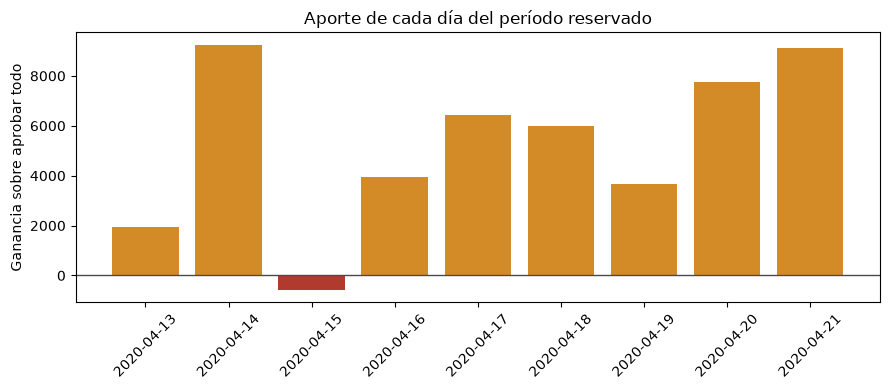

In [4]:
dia = test[DATE].dt.normalize()
por_dia = pd.DataFrame(
    {
        "transacciones": test.groupby(dia).size(),
        "fraude_pct": 100 * test.groupby(dia)[TARGET].mean(),
        "modelo": aporte_modelo.groupby(dia).sum(),
        "regla_score": aporte_score.groupby(dia).sum(),
    }
)
por_dia.index = por_dia.index.date
diario = por_dia.copy()
por_dia.loc["total"] = por_dia.sum()
por_dia.loc["total", "fraude_pct"] = 100 * test[TARGET].mean()
display(por_dia.round(2))

pais = test.g.where(test.g.isin(["BR", "AR", "UY", "US"]), "otros")
por_pais = {}
for nombre, grupo in test.groupby(pais):
    rechaza = rechaza_modelo.loc[grupo.index]
    precision, recall, _, _ = precision_recall_fscore_support(
        grupo[TARGET], rechaza, average="binary", zero_division=0
    )
    por_pais[nombre] = {
        "transacciones": len(grupo),
        "fraude_pct": 100 * grupo[TARGET].mean(),
        "modelo": aporte_modelo.loc[grupo.index].sum(),
        "regla_score": aporte_score.loc[grupo.index].sum(),
        "precision": precision,
        "recall": recall,
    }
por_pais = pd.DataFrame(por_pais).T.sort_values("transacciones", ascending=False)
display(por_pais.round(3))

figura, eje = plt.subplots(figsize=(9, 4))
eje.bar(
    range(len(diario)),
    diario.modelo,
    color=[PALETTE["Fraude"] if valor > 0 else "#B03A2E" for valor in diario.modelo],
)
eje.axhline(0, color="#4A4A4A", linewidth=1)
eje.set(
    xticks=range(len(diario)),
    xticklabels=[str(fecha) for fecha in diario.index],
    ylabel="Ganancia sobre aprobar todo",
    title="Aporte de cada día del período reservado",
)
eje.tick_params(axis="x", rotation=45)
figura.tight_layout()

por_dia.to_csv(MODELS_DIR / "holdout_por_dia.csv")
por_pais.to_csv(MODELS_DIR / "holdout_por_pais.csv")
with mlflow.start_run(run_id=corrida):
    mlflow.log_param("remuestreos_bootstrap", REMUESTREOS)
    mlflow.log_metrics(
        {
            "precision": clasificacion.loc["modelo", "precision"],
            "recall": clasificacion.loc["modelo", "recall"],
            "f1": clasificacion.loc["modelo", "f1"],
            "especificidad": clasificacion.loc["modelo", "especificidad"],
            "ic_bajo": intervalos.loc["modelo", "ic_bajo"],
            "ic_alto": intervalos.loc["modelo", "ic_alto"],
            "dias_con_ganancia": int((diario.modelo > 0).sum()),
        }
    )
    mlflow.log_artifact(str(MODELS_DIR / "holdout_por_dia.csv"))
    mlflow.log_artifact(str(MODELS_DIR / "holdout_por_pais.csv"))
    mlflow.log_figure(figura, "aporte_por_dia.png")

**Lectura: gana 8 de 9 días, y por país se confirma lo de validación.**

**Por día:** el modelo aporta en ocho de los nueve. El que pierde es el **15 de abril, −590**, y no es
casualidad: es el día de menor fraude del período, **2,24%** contra 4,43% del promedio. Con menos fraude
que frenar, los rechazos equivocados no se compensan. Ese mismo día la regla de `score` gana 587, así que
el período no era imposible: el modelo rechazó de más justo cuando menos convenía. Es el mismo fenómeno
que en el fold 0 de `03`, donde la que perdía era la regla de `score`.

**Por país, se confirma lo de validación, y AR queda mejor parada de lo que se temía.** El modelo vuelve a
frenar menos fraude en AR que en BR (recall 0,424 contra 0,505), pero **en AR la regla de `score` pierde
914 y el modelo gana 4.847**: es donde la política actual falla y donde el modelo más cambia las cosas. BR
aporta **+40.188**, el 84% del total, coherente con ser el 71% del volumen y el país de mayor tasa de
fraude (5,09% contra 2,85% de AR).

El único negativo es **UY, −18,5**, con recall 0. Son 723 transacciones con **0,277% de fraude** —dos
casos—, ninguno detectado, y unas pocas legítimas rechazadas. A ese volumen y esa tasa base no hay nada
que concluir: lo honesto es reportarlo y decir que ese mercado no tiene soporte suficiente.

**Nada de esto cambia la decisión**, y no podría: el modelo ya estaba elegido. Lo que agrega es cuánto
confiar en el número y dónde mirar primero en producción — el 15 de abril muestra que los días de fraude
bajo son el escenario incómodo, y UY que hay mercados sin volumen para este modelo.

## 3. Qué mira el modelo

Queda una pregunta que el informe necesita y que ninguna métrica responde: **por qué el modelo rechaza
una transacción**. SHAP reparte la predicción de cada fila entre sus features, así que promediando el
valor absoluto se obtiene cuánto pesa cada una.

**Hipótesis.** Si el EDA acertó, arriba tienen que aparecer `score` y la ausencia de `o`, que era el
patrón que más distinguía el fraude de las compras legítimas en todo el dataset. Y la vara para leer el
resto es **`k`**, que el EDA midió como ruido —AUC 0,5061, independiente de la etiqueta— y que se
conservó justamente para esto: **toda feature que pese menos que `k` está compitiendo con ruido puro.**

Se explica el modelo del último fold sobre su propia validación, de modo que las atribuciones sean sobre
transacciones que ese modelo no entrenó.

17 de 33 features pesan menos que el ruido:
hora_cos, h, es_madrugada, o_Y, hora_sin, a_2, a_4, a_1, missingindicator_d, missingindicator_b, a_3, p_N, missingindicator_m, missingindicator_c, missingindicator_f, missingindicator_l, p_Y


,|SHAP| medio
score,0.8657
o_Ausente,0.6790
g,0.2348
l,0.2118
o_N,0.2065
monto,0.2034
m,0.1942
f,0.1137


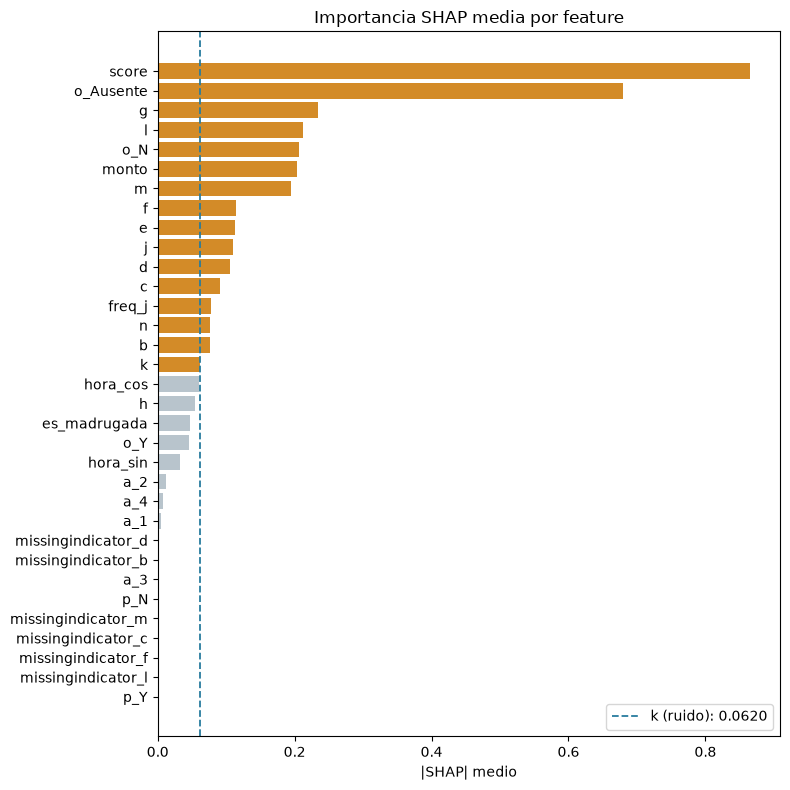

In [5]:
train_pos, valid_pos = folds[-1]
explicado = build_model(XGBClassifier(**AJUSTADO)).fit(X.iloc[train_pos], y.iloc[train_pos])
preprocesador = explicado.named_steps["preprocesamiento"]
matriz = preprocesador.transform(X.iloc[valid_pos])
muestra = np.random.RandomState(RANDOM_STATE).choice(len(matriz), 5000, replace=False)

valores = shap.TreeExplainer(explicado.named_steps["modelo"]).shap_values(matriz[muestra])
importancia = pd.Series(
    np.abs(valores).mean(axis=0), index=preprocesador.get_feature_names_out()
).sort_values()

ruido = importancia["k"]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
    importancia.index,
    importancia.to_numpy(),
    color=[PALETTE["Fraude"] if valor >= ruido else "#B8C4CC" for valor in importancia],
)
ax.axvline(ruido, color="#287C9E", linestyle="--", linewidth=1.3, label=f"k (ruido): {ruido:.4f}")
ax.set(title="Importancia SHAP media por feature", xlabel="|SHAP| medio")
ax.legend()
fig.tight_layout()

print(f"{(importancia < ruido).sum()} de {len(importancia)} features pesan menos que el ruido:")
print(", ".join(reversed(importancia[importancia < ruido].index)))
display(importancia.sort_values(ascending=False).head(8).round(4).to_frame("|SHAP| medio"))

**Lectura: el EDA se sostiene y la variable de control hace su trabajo.**

`score` encabeza con holgura y **`o_Ausente` queda segundo**: la ausencia de `o`, que el EDA identificó
como el patrón de fraude más fuerte, sobrevive a todo el preprocesamiento y es lo segundo que más mueve
al modelo. Después vienen `g`, `l`, `o_N` y `monto`.

Debajo de la línea de `k` quedan **17 de las 33 features**: los seis indicadores de nulo, las cuatro
categorías de `a`, `p_N`, `p_Y`, `o_Y`, `h` y **las tres features temporales**. Que pesen menos que una
variable uniforme e independiente de la etiqueta las vuelve candidatas a poda.

Tres advertencias antes de podar nada:

- **El promedio castiga a las features que afectan a pocas filas.** `es_madrugada` vale para el 3,8% de
  las transacciones, así que promediar su SHAP sobre todas las filas la diluye por construcción. El EDA
  midió que ahí el fraude es 11,59% contra 4,93%: el efecto es real y sigue estando. Para patrones de
  fraude fuertes pero que aparecen en pocas filas hay que mirar el SHAP en el subconjunto donde aplican,
  no la media global.
- **`k` no es un umbral mágico.** Es una medición ruidosa más; una feature apenas por debajo puede
  aportar algo real en otro período.
- **La poda hay que medirla, no deducirla.** Sacar features y comparar ganancia sobre los folds, con la
  misma disciplina que todo lo demás. Y no se puede decidir con este gráfico y validar con el período
  reservado, que ya se usó.

## 4. El artefacto

Lo que se guarda es el **Pipeline entrenado**, no una tabla de features: ahí adentro viajan la
imputación, el one-hot, el target encoding y la codificación por frecuencia, todos ajustados con datos de
entrenamiento. Es lo que permite aplicar el modelo a una transacción nueva sin recalcular nada del
histórico, y la razón por la que `02_feature_engineering.ipynb` verificó esa separación con cuatro
chequeos.

Se guarda junto con el umbral y la fecha hasta la que entrenó, porque un modelo sin su umbral no decide
nada, y se comprueba que al recargarlo devuelva exactamente las mismas probabilidades.

In [6]:
destino = save_model(entrenados["ajustado"], development, UMBRAL)
recuperado = load_model(destino)
np.testing.assert_allclose(
    recuperado["pipeline"].predict_proba(sin_etiqueta)[:, 1], probabilidad_final.to_numpy()
)

with mlflow.start_run(run_name="modelo final"):
    mlflow.log_params({**AJUSTADO, "umbral": UMBRAL})
    mlflow.log_artifact(str(destino))
print(
    f"{destino.relative_to(ROOT)} | {destino.stat().st_size / 1e6:.1f} MB | reproduce las mismas probabilidades"
)

models/xgboost.joblib | 1.1 MB | reproduce las mismas probabilidades


## 5. De acá a producción: qué se rompe y cómo se ve

Un modelo entrenado sobre 36 días no se degrada solo: se degrada porque **el mundo cambia y el modelo
no**. Conviene separar tres cosas que se suelen mezclar bajo la palabra "drift", porque se detectan de
formas distintas:

| Qué cambia | Nombre | Cómo se detecta |
|---|---|---|
| La distribución de las **entradas**: más volumen, otro mix de país, categorías de `j` nuevas | **Data drift** o covariate shift | **Sin etiquetas**, comparando distribuciones contra las de entrenamiento. Es la alarma temprana |
| La **relación** entre entradas y fraude —la probabilidad de fraude *dado* un perfil—: el mismo perfil de transacción deja de significar lo mismo porque el defraudador cambió de método | **Concept drift** | Solo con etiquetas, así que se detecta **tarde**: hay que esperar la confirmación del fraude |
| La **proporción** de fraude | **Label shift** | Con etiquetas. El umbral 0,2 no cambia, pero las probabilidades dejan de corresponder a la tasa real y hay que recalibrarlas |

Sobre **"model drift"**: no es un cuarto mecanismo. El modelo no cambia —es un archivo, hace siempre lo
mismo—; lo que cambia es todo lo demás. "Model drift" es el **efecto** de los tres anteriores, y por eso
no se monitorea directamente: se monitorean las causas.

Faltan dos que no son estadísticas y que en este dataset son riesgos concretos:

- **Cambios aguas arriba.** `score` viene de otro sistema: puede dejar de producirse o cambiar de escala,
  sobre todo si este modelo lo reemplaza. Y el 72% de los valores de `o` son nulos, y esa ausencia es el
  segundo patrón de fraude más importante: si mañana el sistema origen empieza a completar ese campo, o a
  escribir un código en vez de dejarlo vacío, **la feature más fuerte después de `score` cambia de
  significado sin que nada falle**.
- **El lazo de retroalimentación.** Desde el momento en que el modelo rechaza, esas transacciones **no
  tienen resultado**: nunca se sabrá si eran fraude. El próximo entrenamiento solo verá etiquetas de las
  aprobadas, que son las que el modelo consideró seguras. Es un sesgo que se acumula en cada
  reentrenamiento y que no aparece en ninguna métrica de validación.

**Hipótesis para la celda que sigue.** El período reservado es posterior al entrenamiento, así que
debería haber cambios. Si los indicadores que no necesitan etiqueta sirven como alarma temprana, tendrían
que moverse en la misma dirección que los que sí la necesitan: si la tasa real de fraude bajó, la
probabilidad media predicha por el modelo también tendría que bajar, **sin haber visto ninguna etiqueta
para saberlo**.

In [7]:
from fraud_detection.constants import NUMERIC_COLUMNS
from fraud_detection.diagnostics import population_stability_index

vistas_j = set(development.j)

# La referencia de desarrollo tiene que ser FUERA de muestra. El modelo final se
# entrenó con esas filas, así que su probabilidad media en-muestra queda clavada en
# la prevalencia de entrenamiento por construcción del log loss: compararla contra el
# período reservado mide el sobreajuste, no el drift.
fuera_de_fold = pd.Series(np.nan, index=development.index)
for train_pos, valid_pos in folds:
    pliegue = build_model(XGBClassifier(**AJUSTADO)).fit(X.iloc[train_pos], y.iloc[train_pos])
    fuera_de_fold.iloc[valid_pos] = pliegue.predict_proba(X.iloc[valid_pos])[:, 1]

# Las filas del primer bloque de entrenamiento nunca son validación de nadie, así que
# las columnas de probabilidad cubren menos filas que las descriptivas.
probabilidad_de = {
    "entrenamiento": fuera_de_fold.dropna(),
    "reservado": pd.Series(
        entrenados["ajustado"].predict_proba(sin_etiqueta)[:, 1], index=test.index
    ),
}

referencia = {}
for nombre, frame in [("entrenamiento", development), ("reservado", test)]:
    probabilidad = probabilidad_de[nombre]
    referencia[nombre] = {
        "transacciones_por_dia": len(frame) / frame[DATE].dt.normalize().nunique(),
        "monto_medio": frame.monto.mean(),
        "score_medio": frame.score.mean(),
        "nulos_en_o_pct": 100 * frame.o.isna().mean(),
        "j_nunca_vistas_pct": 100 * (~frame.j.isin(vistas_j)).mean(),
        "BR_pct": 100 * frame.g.eq("BR").mean(),
        "AR_pct": 100 * frame.g.eq("AR").mean(),
        "probabilidad_media": probabilidad.mean(),
        "rechazo_pct": 100 * probabilidad.ge(UMBRAL).mean(),
        "fraude_real_pct": 100 * frame[TARGET].mean(),
    }

referencia = pd.DataFrame(referencia)
referencia["variacion_pct"] = 100 * (referencia.reservado / referencia.entrenamiento - 1).replace(
    [np.inf, -np.inf], np.nan
)
display(referencia.round(3))
print(f"probabilidad media fuera de fold sobre {len(fuera_de_fold.dropna()):,} filas de validación")

# j queda afuera: con 7.770 categorías su PSI mediría ruido. La vigila j_nunca_vistas_pct.
estabilidad = pd.Series(
    {
        columna: population_stability_index(development[columna], test[columna])
        for columna in NUMERIC_COLUMNS + ["a", "g", "n", "o", "p"]
    }
)
estabilidad["probabilidad del modelo"] = population_stability_index(
    probabilidad_de["entrenamiento"], probabilidad_de["reservado"]
)
estabilidad = estabilidad.sort_values(ascending=False).rename("psi").to_frame()
display(estabilidad.round(4))
print(
    f"PSI mayor a 0,1: {', '.join(estabilidad.index[estabilidad.psi.gt(0.1)]) or 'ninguna'} | "
    f"mayor a 0,25: {', '.join(estabilidad.index[estabilidad.psi.gt(0.25)]) or 'ninguna'}"
)

referencia.to_csv(MODELS_DIR / "ficha_de_monitoreo.csv")
estabilidad.to_csv(MODELS_DIR / "psi_de_referencia.csv")
with mlflow.start_run(run_name="ficha de monitoreo"):
    mlflow.log_artifact(str(MODELS_DIR / "ficha_de_monitoreo.csv"))
    mlflow.log_artifact(str(MODELS_DIR / "psi_de_referencia.csv"))

,entrenamiento,reservado,variacion_pct
transacciones_por_dia,3180.722,3943.778,23.990
monto_medio,43.952,42.138,-4.128
score_medio,49.123,44.657,-9.093
nulos_en_o_pct,72.498,72.809,0.430
j_nunca_vistas_pct,0.000,1.924,NaN
BR_pct,75.490,70.961,-6.000
AR_pct,20.416,24.193,18.502
probabilidad_media,0.048,0.048,-0.970
rechazo_pct,5.584,5.438,-2.619
fraude_real_pct,5.178,4.426,-14.519


probabilidad media fuera de fold sobre 87,145 filas de validación


,psi
score,0.0415
g,0.0119
b,0.0075
probabilidad del modelo,0.0056
monto,0.0041
e,0.0040
h,0.0034
a,0.0033
d,0.0025
f,0.0024


PSI mayor a 0,1: ninguna | mayor a 0,25: ninguna


**Lectura: el drift de entradas se ve sin etiquetas; la caída del fraude, no.**

Entre los dos períodos cambió bastante, y **esta parte sí se ve sin conocer una sola etiqueta**: el
volumen diario subió **24%**, la participación de BR bajó de 75,5% a 71,0% mientras AR subió de 20,4%
a 24,2%, el `score` medio bajó de 49,1 a 44,7, y un **1,92%** de las transacciones trae una categoría
de `j` que el modelo nunca vio. Eso es data drift, en nueve días.

**El PSI lo mide sobre la distribución completa, y confirma que el cambio es chico.** El PSI (Population
Stability Index) compara la distribución de cada columna contra la de entrenamiento; por debajo de 0,1
se considera estable. Ninguna lo supera: la mayor es `score`, con 0,0415, y la probabilidad del modelo
queda en 0,0056.

**Pero la alarma temprana no disparó, y conviene decirlo.** Comparada contra la referencia correcta
—las predicciones fuera de fold, no las de entrenamiento— la probabilidad media del modelo pasó de
**0,0480 a 0,0475: −1,0%**, y el porcentaje de rechazo de 5,58% a 5,44%. Prácticamente planos,
mientras la tasa real de fraude caía de 5,18% a 4,43%, un **−14,5%**. El modelo no vio venir el cambio.

**Y esto es coherente con la taxonomía de arriba, no una contradicción.** El *data drift* se detecta
sin etiquetas y acá se detectó. La caída de la tasa de fraude es *label shift*, y la propia tabla dice que
necesita etiquetas. Lo que el experimento agrega es la confirmación empírica: **no hay atajo sin
etiquetas para enterarse de que el fraude bajó.** El monitoreo diario sirve para disparar una
revisión cuando cambian las entradas, y nada más — la ganancia realizada hay que esperarla.

La estabilidad también informa: los nulos de `o` se mantuvieron en 72,5% contra 72,8%, así que el
comportamiento del sistema de origen no cambió en el campo del que más depende el modelo.

**El plan de monitoreo que sale de esto**, en tres niveles:

| Cuándo | Qué se mira | Qué dispara |
|---|---|---|
| **Diario, sin etiquetas** (data drift) | PSI de cada columna y de la probabilidad del modelo, volumen, mix por país, nulos por columna, % de `j` nuevas y % de rechazo | Revisión si el PSI de alguna columna supera 0,1 |
| **Cuando llegan las etiquetas** (concept drift y label shift) | Ganancia realizada contra la esperada, tasa de fraude, calibración por decil, AUC y average precision | Recalibrar si cambió la tasa de fraude; reentrenar si la ganancia cae con la tasa estable |
| **Continuo** | Que `score` siga llegando y con la misma escala | Cambiar al modelo sin `score`, que ya está entrenado y medido (+37.867) |

Tres decisiones operativas que se siguen de todo el trabajo:

- **La frecuencia de reentrenamiento la fija la demora de las etiquetas**, no el calendario. Reentrenar
  con datos cuya etiqueta todavía no se confirmó es entrenar con ruido; la sección 2 de `03` midió que
  esperar hasta una semana cuesta alrededor del 8%.
- **El umbral no se toca.** Sale de la regla de negocio, no de los datos: si cambian los costos, cambia
  el umbral; si cambian los datos, se recalibra el modelo.
- **Guardar la probabilidad de cada transacción, incluidas las rechazadas.** Es lo único que después
  permite estimar cuánto se está perdiendo por el lazo de retroalimentación, y sin eso el sesgo es
  invisible.

## Conclusión

**El modelo final es un solo XGBoost para todos los países, con los hiperparámetros de
`04_tuning.ipynb`, sin reponderar las clases y con el umbral 0,2 que sale de despejar la regla de negocio.**
Sobre los 9 días reservados agrega **+47.567** contra aprobar todo y **+24.366** contra la regla de un
corte sobre `score`. El número tiene ruido —de **37.317 a 58.125**— pero la ventaja no: el intervalo de
la diferencia, **[16.416, 32.749]**, no toca el cero.

**Sobre `score`.** Sin esa columna la cifra es **+37.867**, 1,6 veces la referencia. Se entrega el
modelo con `score` por ser el de mayor ganancia medida: las tres huellas de fuga que buscó el EDA no
aparecieron. Pero **compatible no es confirmado**, así que el modelo sin `score` queda como prueba de
sensibilidad y fallback operativo. La misma exigencia *point-in-time* corre para `o`, que no tiene un
fallback medido.

**Pendiente:** la poda de las 17 features que quedaron por debajo de `k`, medida sobre los folds y no
deducida del gráfico de SHAP, que no se puede validar con el período reservado porque ya se usó.